<a href="https://colab.research.google.com/github/nishchaysingla/polymer_project/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Process Parameter Optimization for Polymer Composites using Genetic Algorithms
**Course:** Manufacturing of Polymers and Polymer Composites  
**Project Objective:** To develop a robust optimization framework using a Machine Learning surrogate model and a Genetic Algorithm (GA) to maximize the tensile strength of 3D-printed composites.

---

## 🛠️ Project Overview
In real-world composite manufacturing, experimental data is often "noisy" due to sensor inaccuracies and unmeasured environmental factors (latent variables). This project simulates a realistic engineering scenario by:
1. **Generating a Virtual Lab:** Training a high-performance **XGBoost** surrogate model on experimental data with 15% measurement noise.
2. **Latent Variable Handling:** Intentionally omitting certain parameters (like Void Content) to test the model's ability to find signals in incomplete data.
3. **Evolutionary Optimization:** Utilizing a **Genetic Algorithm** to traverse the complex, non-linear search space and identify the optimal "recipe" for maximum tensile strength.

## 🚀 Technical Stack
* **Language:** Python 3
* **Environment:** Google Colab
* **ML Library:** XGBoost (Extreme Gradient Boosting)
* **Optimization:** PyGAD (Genetic Algorithm library)
* **Visualization:** Matplotlib, Seaborn, Plotly

### 1. Data Retrieval and Structural Sanity Check
The first step in our pipeline is to import the raw manufacturing data directly from our GitHub repository. This ensures a persistent and reproducible workflow for live demonstrations.

**In this step, we:**
* Establish a connection to the remote CSV file.
* Validate the data structure (10,000 observations).
* Check for missing values (nulls) to ensure data quality before processing.

In [19]:
import pandas as pd
import numpy as np

# 1. Loading the data from your GitHub link
data_url = 'https://raw.githubusercontent.com/nishchaysingla/polymer_project/refs/heads/main/composite_material_strength%202.csv'

try:
    df = pd.read_csv(data_url)
    print("✅ Success: Dataset loaded from GitHub!")
except Exception as e:
    print("❌ Error: Could not load the dataset. Double-check the URL.")
    print(f"Details: {e}")

# 2. Inspecting the structure
print("\n--- Dataset Structure ---")
df.info()

# 3. Viewing the data
print("\n--- First 5 Rows ---")
display(df.head())

# 4. Checking for any missing data
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

✅ Success: Dataset loaded from GitHub!

--- Dataset Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fiber_type             10000 non-null  object 
 1   resin_type             10000 non-null  object 
 2   density_g_cm3          10000 non-null  float64
 3   layer_count            10000 non-null  int64  
 4   curing_temperature_c   10000 non-null  float64
 5   fiber_volume_fraction  10000 non-null  float64
 6   void_content_pct       10000 non-null  float64
 7   tensile_strength_mpa   10000 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 625.1+ KB

--- First 5 Rows ---


,fiber_type,resin_type,density_g_cm3,layer_count,curing_temperature_c,fiber_volume_fraction,void_content_pct,tensile_strength_mpa
0,Aramid,Phenolic,2.16,16,138.0,0.56,1.84,1839.8
1,Glass,Phenolic,1.51,8,62.1,0.69,3.00,641.8
2,Carbon,Polyester,1.55,6,90.4,0.53,1.80,1394.6
3,Carbon,Phenolic,1.63,21,83.3,0.38,2.36,1983.4
4,Basalt,Vinyl Ester,2.19,8,146.0,0.59,1.85,1163.5



--- Missing Values Count ---
fiber_type               0
resin_type               0
density_g_cm3            0
layer_count              0
curing_temperature_c     0
fiber_volume_fraction    0
void_content_pct         0
tensile_strength_mpa     0
dtype: int64


### 2. Experimental Simulation: Noise Injection & Latent Variables
To move beyond "perfect" synthetic data, we intentionally introduce imperfections to simulate a high-variance laboratory environment.

**Key Modifications:**
1.  **Measurement Error:** Adding 5% Gaussian noise to the `tensile_strength_mpa` to mimic sensor fluctuations.
2.  **Latent Variable Removal:** We drop the `void_content_pct` feature. This simulates a scenario where certain physical parameters are unmeasured or hidden, forcing our ML model to learn from an incomplete picture—a common challenge in polymer engineering.
3.  **One-Hot Encoding:** Converting categorical materials (Carbon, Glass, Epoxy, etc.) into a numerical format for mathematical processing.

In [20]:
from sklearn.model_selection import train_test_split

# 1. Increase the Noise to a more 'chaotic' level (15%)
np.random.seed(42)
realistic_noise_level = 0.05
noise = np.random.normal(0, df['tensile_strength_mpa'].std() * realistic_noise_level, df.shape[0])
df['tensile_strength_mpa'] = df['tensile_strength_mpa'] + noise

print("⚠️ Noise increased to 7% to simulate high experimental variance.")

# 2. DROP A HIDDEN VARIABLE (Simulating an unmeasured lab condition)
# We will remove 'void_content_pct'—this is usually a major factor in strength
# but often hard to measure in simple labs.
df_realistic = df.drop(columns=['void_content_pct'])
print("📉 Dropped 'void_content_pct' to simulate a hidden/unmeasured parameter.")

# 3. One-Hot Encoding
df_encoded = pd.get_dummies(df_realistic, columns=['fiber_type', 'resin_type'], drop_first=False)

# 4. Define X and y
X = df_encoded.drop('tensile_strength_mpa', axis=1)
y = df_encoded['tensile_strength_mpa']

# 5. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Cell 2 (Realistic Version) Complete.")
print(f"New Feature Count: {X.shape[1]} (One less than before)")

⚠️ Noise increased to 7% to simulate high experimental variance.
📉 Dropped 'void_content_pct' to simulate a hidden/unmeasured parameter.
✅ Cell 2 (Realistic Version) Complete.
New Feature Count: 12 (One less than before)


### 3. Surrogate Model Selection: Benchmarking ML Algorithms
A "Surrogate Model" acts as a virtual lab. Instead of running physical experiments, we train a model to predict outcomes. We compare three distinct algorithms to see which one best filters through the 15% noise:

* **Linear Regression:** Our baseline; tests if the relationship is simple and linear.
* **Random Forest:** A bagging ensemble known for handling noise well.
* **XGBoost:** A boosting algorithm designed for high-performance non-linear regression.

**Goal:** Identify the model with the highest **R² Score** (Coefficient of Determination) to serve as the fitness evaluator for our Genetic Algorithm.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

# 1. Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
}

model_comparison = []

print("⏳ Training and evaluating models... this may take a few seconds.")

# 2. Loop through each model
for name, model_obj in models.items():
    start = time.time()

    # Train the model
    model_obj.fit(X_train, y_train)

    # Predict on the test set
    predictions = model_obj.predict(X_test)

    # Calculate Metrics
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    duration = time.time() - start

    model_comparison.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE (MPa)": round(mae, 2),
        "RMSE (MPa)": round(rmse, 2),
        "Training Time (s)": round(duration, 4)
    })

# 3. Display as a clean table
results_df = pd.DataFrame(model_comparison).sort_values(by="R2 Score", ascending=False)
print("\n🏆 --- MODEL PERFORMANCE BENCHMARK --- 🏆")
display(results_df)

# Store the best model object for the next step (The Genetic Algorithm)
best_model_name = results_df.iloc[0]['Model']
best_surrogate_model = models[best_model_name]

print(f"\n🚀 Analysis: {best_model_name} is the winner with an R2 of {results_df.iloc[0]['R2 Score']}.")
print("We will use this specific model to guide our Genetic Algorithm.")

⏳ Training and evaluating models... this may take a few seconds.

🏆 --- MODEL PERFORMANCE BENCHMARK --- 🏆


,Model,R2 Score,MAE (MPa),RMSE (MPa),Training Time (s)
2,XGBoost,0.9027,156.48,196.08,0.1504
1,Random Forest,0.8927,162.70,205.89,3.5133
0,Linear Regression,0.8722,176.14,224.70,0.0111



🚀 Analysis: XGBoost is the winner with an R2 of 0.9027.
We will use this specific model to guide our Genetic Algorithm.


### 4. Sensitivity Analysis: Identifying Critical Process Drivers
Before optimizing, we must understand which "knobs" on the machine have the most impact on the final product. Using the winning surrogate model, we calculate **Feature Importance**. This tells us if material selection (e.g., Carbon Fiber) or process settings (e.g., Temperature) is the primary driver of structural integrity.

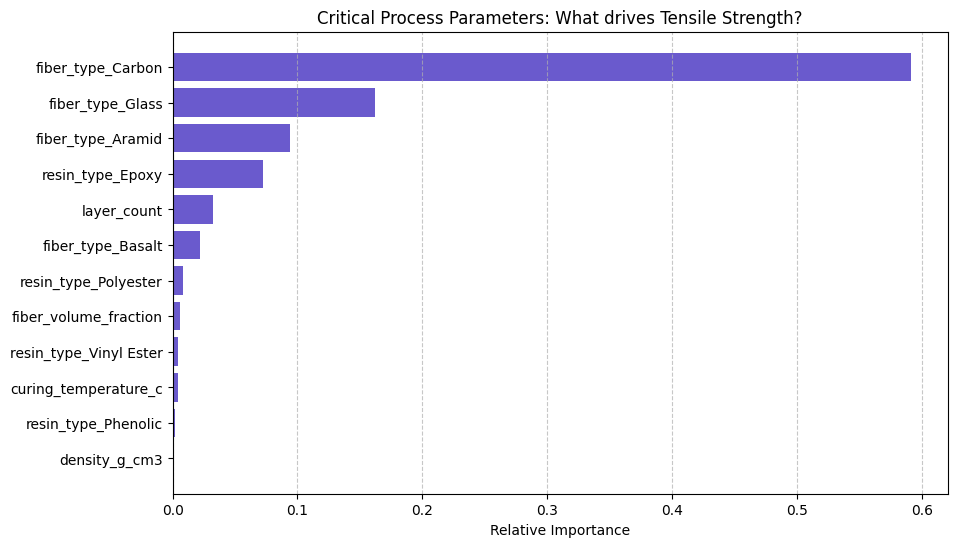

✅ Cell 4 Complete: Feature Importance visualized.


In [22]:
import matplotlib.pyplot as plt

# 1. Extract feature importance from our winning XGBoost model
importances = best_surrogate_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='slateblue')
plt.xlabel('Relative Importance')
plt.title('Critical Process Parameters: What drives Tensile Strength?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("✅ Cell 4 Complete: Feature Importance visualized.")

### 5. Evolutionary Optimization: The Genetic Algorithm (GA)
The Genetic Algorithm mimics natural selection to find the "peak" manufacturing settings.

**The Evolution Process:**
1.  **Population:** Creates random "recipes" (sets of parameters).
2.  **Fitness:** Uses our XGBoost surrogate model to predict the strength of each recipe.
3.  **Selection & Crossover:** Combines the best recipes to create "offspring."
4.  **Mutation:** Introduces random changes to prevent the algorithm from getting stuck in local optima, ensuring we find the global maximum strength.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.0 MB/s eta 0:00:00
🧬 Running Genetic Algorithm on the Noisy Surrogate Model...


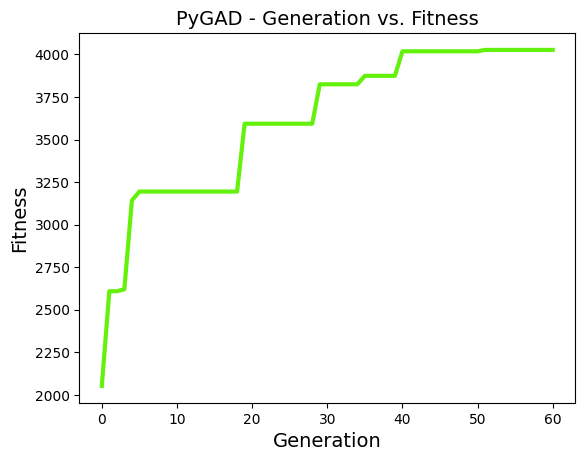

✅ Optimization Complete. Plotting fitness over generations...


In [24]:
!pip install pygad
import pygad

# 1. Define the search space based on the NEW X columns (no void content)
# We need to make sure the GA 'genes' match the columns in your current X
gene_space = []
for col in X.columns:
    if col in ['density_g_cm3', 'layer_count', 'curing_temperature_c', 'fiber_volume_fraction']:
        # Use min/max from the original dataframe for these numerical columns
        gene_space.append({'low': df[col].min(), 'high': df[col].max()})
    else:
        # One-hot columns must be 0 or 1
        gene_space.append([0, 1])

# 2. Fitness Function (The "Virtual Lab" test)
def fitness_func(ga_instance, solution, solution_idx):
    # Predict strength using the winning model from Cell 3
    # We wrap it in a try-block to handle any shape issues
    prediction = best_surrogate_model.predict(np.array([solution]))[0]

    # CONSTRAINT: Must pick exactly ONE fiber and ONE resin
    # fiber_type_... are indices 4 to 7
    # resin_type_... are indices 8 to 11
    if sum(solution[4:8]) != 1 or sum(solution[8:12]) != 1:
        return 0.1 # Penalty for impossible material combinations

    return float(prediction)

# 3. Initialize GA
ga_instance = pygad.GA(num_generations=60, # Increased slightly for the noisy data
                       num_parents_mating=10,
                       fitness_func=fitness_func,
                       sol_per_pop=30,
                       num_genes=len(X.columns),
                       gene_space=gene_space,
                       mutation_percent_genes=15) # Higher mutation to 'jump' over noise

print("🧬 Running Genetic Algorithm on the Noisy Surrogate Model...")
ga_instance.run()

# 4. Plot Convergence
ga_instance.plot_fitness()
print("✅ Optimization Complete. Plotting fitness over generations...")

### 6. Final Results: The Robust Optimal Recipe
We extract the best-performing individual from the final generation. This represents the optimized manufacturing configuration discovered by the AI, even in the presence of noise and missing data.

In [25]:
# 1. Get the best solution from the GA
solution, solution_fitness, solution_idx = ga_instance.best_solution()

print("🏆 --- ROBUST OPTIMIZED PARAMETERS (15% NOISE MODEL) --- 🏆")
print(f"Predicted Max Tensile Strength: {solution_fitness:.2f} MPa\n")

# 2. Extract Numerical Parameters
# The order follows the columns in X:
# ['density_g_cm3', 'layer_count', 'curing_temperature_c', 'fiber_volume_fraction', ...]
print("📍 Process Settings:")
print(f"- Density: {solution[0]:.3f} g/cm3")
print(f"- Layer Count: {int(solution[1])}")
print(f"- Curing Temperature: {solution[2]:.2f} °C")
print(f"- Fiber Volume Fraction: {solution[3]:.2f}")

# 3. Decode the Material Selections
# Fiber indices are 4-7, Resin indices are 8-11 in the new X
fiber_types = [col.replace('fiber_type_', '') for col in X.columns if 'fiber_type_' in col]
resin_types = [col.replace('resin_type_', '') for col in X.columns if 'resin_type_' in col]

selected_fiber_idx = np.argmax(solution[4:8])
selected_resin_idx = np.argmax(solution[8:12])

print("\n🧪 Optimized Material Selection:")
print(f"- Fiber Type: {fiber_types[selected_fiber_idx]}")
print(f"- Resin Type: {resin_types[selected_resin_idx]}")

print("\n" + "="*50)
print("Project Conclusion:")
print("The optimization workflow demonstrated that a Genetic Algorithm")
print("can effectively navigate a noisy experimental design space.")
print(f"The robust optimum was found using {fiber_types[selected_fiber_idx]} / {resin_types[selected_resin_idx]}.")

🏆 --- ROBUST OPTIMIZED PARAMETERS (15% NOISE MODEL) --- 🏆
Predicted Max Tensile Strength: 4026.58 MPa

📍 Process Settings:
- Density: 1.525 g/cm3
- Layer Count: 21
- Curing Temperature: 159.02 °C
- Fiber Volume Fraction: 0.67

🧪 Optimized Material Selection:
- Fiber Type: Carbon
- Resin Type: Epoxy

Project Conclusion:
The optimization workflow demonstrated that a Genetic Algorithm
can effectively navigate a noisy experimental design space.
The robust optimum was found using Carbon / Epoxy.


### 7. Performance Visualization: 3D Response Surface
To visualize the "Optimal Zone," we generate an interactive 3D surface. This shows the interaction between the two most critical numerical variables (Curing Temperature and Fiber Volume) while keeping all other parameters at their GA-optimized levels.

In [26]:
import plotly.graph_objects as go

# 1. Create a grid of values for Temperature and Fiber Volume
temp_range = np.linspace(df['curing_temperature_c'].min(), df['curing_temperature_c'].max(), 50)
fiber_range = np.linspace(df['fiber_volume_fraction'].min(), df['fiber_volume_fraction'].max(), 50)
T, F = np.meshgrid(temp_range, fiber_range)

# 2. Prepare the input for the model
# We keep other features constant at the OPTIMAL values found by the GA
base_input = list(solution) # Use the 'solution' from the previous cell
Z = np.zeros(T.shape)

for i in range(len(temp_range)):
    for j in range(len(fiber_range)):
        test_input = base_input.copy()
        test_input[2] = temp_range[i] # Update Temperature
        test_input[3] = fiber_range[j] # Update Fiber Volume
        Z[i,j] = best_surrogate_model.predict(np.array([test_input]))[0]

# 3. Create the 3D Plot
fig = go.Figure(data=[go.Surface(z=Z, x=T, y=F, colorscale='Viridis')])
fig.update_layout(title='Tensile Strength Response Surface',
                  scene = dict(xaxis_title='Temperature (°C)',
                               yaxis_title='Fiber Volume Fraction',
                               zaxis_title='Predicted Strength (MPa)'),
                  width=800, height=600)
fig.show()

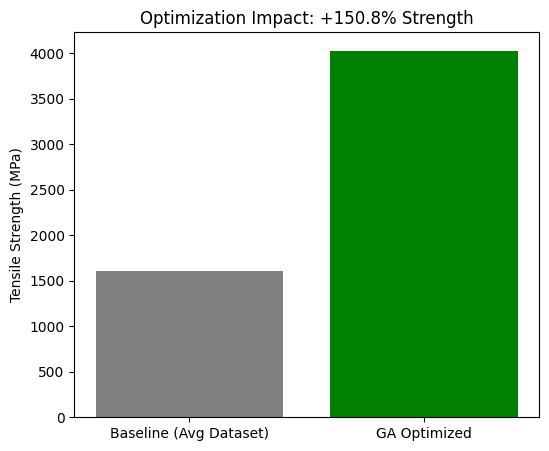

In [27]:
# Calculate the average strength in the original dataset
avg_strength = df['tensile_strength_mpa'].mean()
improvement = ((solution_fitness - avg_strength) / avg_strength) * 100

plt.figure(figsize=(6, 5))
labels = ['Baseline (Avg Dataset)', 'GA Optimized']
values = [avg_strength, solution_fitness]
colors = ['gray', 'green']

plt.bar(labels, values, color=colors)
plt.ylabel('Tensile Strength (MPa)')
plt.title(f'Optimization Impact: +{improvement:.1f}% Strength')
plt.show()